# Customer Churn Prediction using Artificial Neural Network (ANN)
**Course:** Advanced Deep Learning (DL-501)
**Assignment:** Deep Learning Assignment 01
**Framework:** TensorFlow / Keras & Scikit-Learn

This notebook implements the complete deep learning pipeline for predicting customer churn on the Telco Customer Churn dataset: exploratory data analysis, preprocessing, ANN construction, training, and multi-metric evaluation.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, classification_report,ConfusionMatrixDisplay)

# Lock random seeds globally for reproducibility across machines
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

## Part 1 – Data Exploration

We begin by loading the raw Telco Customer Churn dataset and performing a meticulous inspection of its structure, data types, missing values, descriptive statistics, and target class balance.

In [18]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
# Structural metadata: dtypes and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [20]:
# Missing / corrupted field entries per column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [21]:
# Descriptive statistics for numeric fields
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


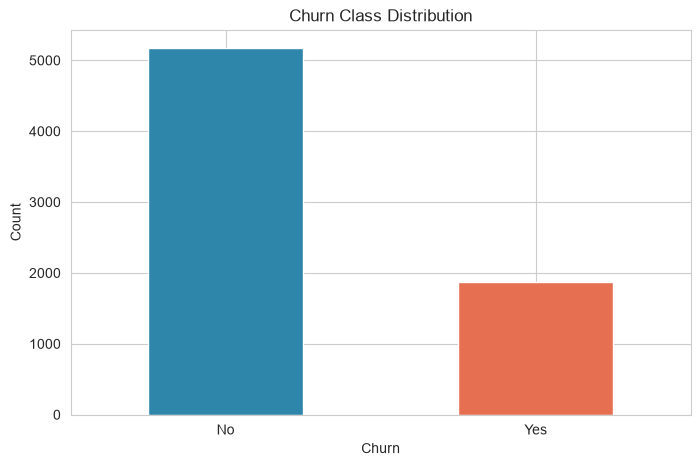

In [22]:
# Target variable distribution (class imbalance check)
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(4) * 100)

df['Churn'].value_counts().plot(kind='bar', color=['#2E86AB', '#E76F51'])
plt.title("Churn Class Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

**Observation:** `TotalCharges` is loaded as an object/string column even though it is numeric — this indicates hidden blank-character entries that need remediation. The target `Churn` is imbalanced (~73% No vs ~27% Yes), which will need to be accounted for during evaluation.

## Part 2 – Data Preprocessing Pipeline

### 2.1 Missing Value Remediation
`TotalCharges` contains blank-string entries (customers with `tenure = 0`, i.e. brand-new accounts). We coerce these to numeric, convert blanks to `NaN`, and impute with the median.

In [23]:
# Reveal hidden blank entries in TotalCharges and convert to numeric
blank_mask = df['TotalCharges'].str.strip() == ''
print("Blank TotalCharges entries:", blank_mask.sum())

df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
print("Nulls after coercion:", df['TotalCharges'].isnull().sum())

median_total_charges = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_total_charges)
print("Nulls after median imputation:", df['TotalCharges'].isnull().sum())

Blank TotalCharges entries: 11
Nulls after coercion: 11
Nulls after median imputation: 0


### 2.2 Dimensional Pruning
Drop non-predictive identifier columns with zero variance / predictive value.

In [24]:
df = df.drop(columns=['customerID'])
df.shape

(7043, 20)

### 2.3 Categorical Variable Transformations
Two-state (binary) categorical fields are label-encoded to 0/1. Nominal fields with three or more categories are one-hot encoded.

In [25]:
categorical_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
categorical_cols.remove('Churn')  # target handled separately

binary_cols = [c for c in categorical_cols if df[c].nunique() == 2]
multi_cols = [c for c in categorical_cols if df[c].nunique() > 2]

print("Binary-encoded columns:", binary_cols)
print("One-hot encoded columns:", multi_cols)

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
df.shape

Binary-encoded columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
One-hot encoded columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


(7043, 31)

### 2.4 Target Variable Conversion

In [26]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

### 2.5 Feature Scaling & 2.6 Validation Partitioning
Split first (80/20 train/test), then fit the scaler only on the training partition to avoid data leakage, applying Z-score standardization to the continuous numerical variables.

In [27]:
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

X_train_scaled = X_train_scaled.astype('float32')
X_test_scaled = X_test_scaled.astype('float32')

print("Training set:", X_train_scaled.shape)
print("Testing set:", X_test_scaled.shape)
print("Total input features fed to the network:", X_train_scaled.shape[1])

Training set: (5634, 30)
Testing set: (1409, 30)
Total input features fed to the network: 30


## Part 3 – Artificial Neural Network Architecture

A sequential feedforward network with two ReLU hidden layers (32 → 16 neurons) and a single sigmoid output neuron for binary classification.

In [28]:
n_features = X_train_scaled.shape[1]

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_features,), name="input_layer"),
    tf.keras.layers.Dense(32, activation='relu', name="hidden_layer_1"),
    tf.keras.layers.Dense(16, activation='relu', name="hidden_layer_2"),
    tf.keras.layers.Dense(1, activation='sigmoid', name="output_layer"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)               │ (None, 32)                  │             992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_layer_2 (Dense)               │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output_layer (Dense)                 │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

## Part 4 – Optimization Configuration

- **Optimizer:** Adam (default learning-rate settings)
- **Loss:** Binary Crossentropy
- **Metric:** Accuracy

In [29]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Part 5 – Training Execution

Train for exactly 50 epochs, batch size 32, holding out 20% of the training partition internally for validation.

In [30]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7431 - loss: 0.5102 - val_accuracy: 0.7835 - val_loss: 0.4562
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8016 - loss: 0.4230 - val_accuracy: 0.7835 - val_loss: 0.4478
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8067 - loss: 0.4125 - val_accuracy: 0.7791 - val_loss: 0.4431
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8101 - loss: 0.4077 - val_accuracy: 0.7808 - val_loss: 0.4429
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8114 - loss: 0.4051 - val_accuracy: 0.7844 - val_loss: 0.4422
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8112 - loss: 0.4031 - val_accuracy: 0.7879 - val_loss: 0.4421
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8118 - loss: 0.4015 - val_accuracy: 0.7870 - val_loss: 0.4421
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8143 - loss: 0.4000 - val_accuracy: 0

## Part 6 – Model Evaluation

In [31]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.4492
Test Accuracy: 0.7743


In [32]:
# Part 8 -- Predictions on the test partition using a 0.5 threshold
y_prob = model.predict(X_test_scaled, verbose=0)
y_pred = (y_prob > 0.5).astype(int).flatten()

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.7743
Precision: 0.5707
Recall:    0.6043
F1-score:  0.5870


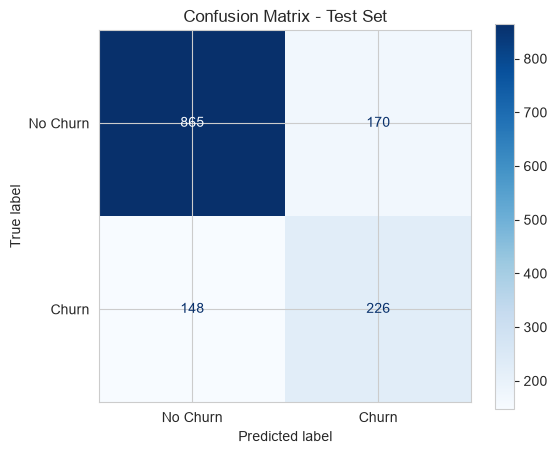

True Negatives:  865
False Positives: 170
False Negatives: 148
True Positives:  226


In [33]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Test Set")
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

In [34]:
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.84      1035
       Churn       0.57      0.60      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.77      0.78      1409



In [35]:
# Directly contrast predictions vs true labels
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Churn_Probability': y_prob.flatten().round(4)
}).reset_index(drop=True)
comparison_df.head(15)

,Actual,Predicted,Churn_Probability
0,0,0,0.0570
1,0,1,0.8269
2,0,0,0.0888
3,0,1,0.5461
4,0,0,0.0165
5,0,1,0.7898
6,0,0,0.4166
7,0,0,0.1127
8,0,0,0.0028
9,1,1,0.5235


## Part 7 – Visualization: Learning Curves

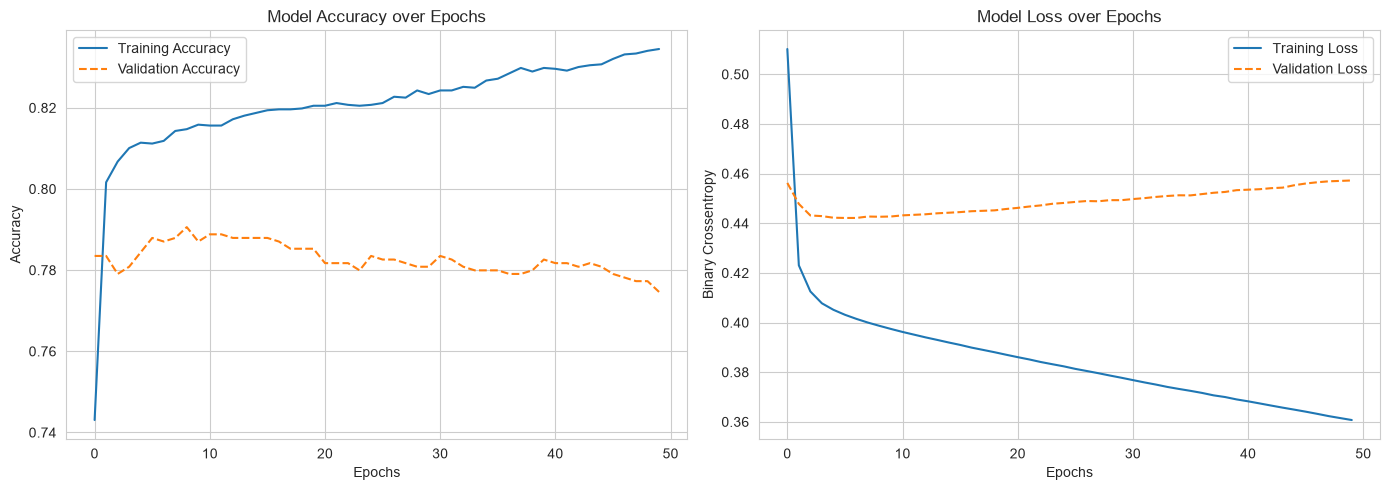

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Binary Crossentropy')
axes[1].legend()

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150, bbox_inches='tight')
plt.show()

## Save Trained Model

Serialize the fully trained network (weights, architecture, and optimizer state) after epoch 50.

In [37]:
model.save("churn_ann_model.keras")
print("Model saved to churn_ann_model.keras")

Model saved to churn_ann_model.keras


In [38]:
import tensorflow as tf
print(tf.__version__)

2.21.0


## Summary of Results

| Metric | Value |
|---|---|
| Test Accuracy | see printed value above |
| Precision (Churn class) | see classification report |
| Recall (Churn class) | see classification report |
| F1-score (Churn class) | see classification report |

The model shows a noticeable gap between precision/recall on the majority ("No Churn") class versus the minority ("Churn") class, a direct consequence of the ~73/27 class imbalance in the source data. This is discussed further in the accompanying Analytical Summary Report.